In [47]:
import json
import random
from pathlib import Path
from collections import Counter, defaultdict

In [48]:
PROJECT_ROOT = Path(
    "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8"
)

TACO_ROOT = PROJECT_ROOT / "data" / "taco_raw" / "TACO"
TACO_DATA = TACO_ROOT / "data"
TACO_IMAGES = TACO_ROOT / "images"

In [49]:
with open(TACO_DATA / "annotations.json", "r") as f:
    taco_data = json.load(f)

In [50]:
YOLO_CLASSES = [
    "biodegradable",
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic"
]

In [8]:
YOLO_CLASSES = [
    "biodegradable",
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic"
]

CLASS_TO_ID = {
    name: idx
    for idx, name in enumerate(YOLO_CLASSES)
}

print(CLASS_TO_ID)

{'biodegradable': 0, 'cardboard': 1, 'glass': 2, 'metal': 3, 'paper': 4, 'plastic': 5}


In [51]:
TACO_TO_EXISTING = {
    "Drink can": "metal",
    "Clear plastic bottle": "plastic",
    "Other plastic bottle": "plastic",
    "Glass bottle": "glass",
    "Paper cup": "paper",
    "Corrugated carton": "cardboard",
    "Other carton": "cardboard",
    "Normal paper": "paper",
    "Food waste": "biodegradable",
}

In [52]:
CLASS_TO_ID = {
    name: idx
    for idx, name in enumerate(YOLO_CLASSES)
}

TACO_CATEGORY_TO_YOLO = {}

for category in taco_data["categories"]:

    taco_name = category["name"]

    if taco_name in TACO_TO_EXISTING:

        existing_class = TACO_TO_EXISTING[taco_name]

        yolo_id = CLASS_TO_ID[existing_class]

        TACO_CATEGORY_TO_YOLO[
            category["id"]
        ] = yolo_id

In [53]:
import shutil

TACO_FINAL_DIR = PROJECT_ROOT / "data" / "taco_yolo_final"

if TACO_FINAL_DIR.exists():
    shutil.rmtree(TACO_FINAL_DIR)

TACO_FINAL_IMAGES = TACO_FINAL_DIR / "images"
TACO_FINAL_LABELS = TACO_FINAL_DIR / "labels"

TACO_FINAL_IMAGES.mkdir(parents=True, exist_ok=True)
TACO_FINAL_LABELS.mkdir(parents=True, exist_ok=True)

print("Created:")
print(TACO_FINAL_DIR)

Created:
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/taco_yolo_final


In [54]:
import requests
from io import BytesIO
from PIL import Image
from collections import defaultdict, Counter
from pathlib import Path

# ---------------------------------------------------------
# Build image lookup
# ---------------------------------------------------------

image_lookup = {
    image["id"]: image
    for image in taco_data["images"]
}


# ---------------------------------------------------------
# Group ONLY selected annotations by image
# ---------------------------------------------------------

selected_by_image = defaultdict(list)

for ann in taco_data["annotations"]:

    category_id = ann["category_id"]

    if category_id in TACO_CATEGORY_TO_YOLO:
        selected_by_image[ann["image_id"]].append(ann)


# ---------------------------------------------------------
# COCO → YOLO
# ---------------------------------------------------------

def coco_to_yolo_bbox(
    bbox,
    image_width,
    image_height
):

    x, y, w, h = bbox

    x_center = (x + w / 2) / image_width
    y_center = (y + h / 2) / image_height

    w_norm = w / image_width
    h_norm = h / image_height

    return (
        x_center,
        y_center,
        w_norm,
        h_norm
    )


# ---------------------------------------------------------
# Download + conversion
# ---------------------------------------------------------

converted_images = 0
converted_annotations = 0

class_counts = Counter()

failed_downloads = []


for image_id, anns in selected_by_image.items():

    image_info = image_lookup[image_id]

    original_path = Path(
        image_info["file_name"]
    )

    # -----------------------------------------------------
    # UNIQUE filename
    # -----------------------------------------------------

    # batch_1/000006.jpg
    #
    # →
    #
    # taco_batch_1_000006.jpg

    safe_name = "_".join(
        original_path.parts
    )

    output_name = f"taco_{safe_name}"

    image_output_path = (
        TACO_FINAL_IMAGES / output_name
    )

    label_output_path = (
        TACO_FINAL_LABELS
        / f"{Path(output_name).stem}.txt"
    )


    # -----------------------------------------------------
    # Download original image
    # -----------------------------------------------------

    url = image_info["flickr_url"]

    try:

        response = requests.get(
            url,
            timeout=60
        )

        response.raise_for_status()

        image = Image.open(
            BytesIO(response.content)
        )

        image = image.convert("RGB")

        # Save as JPEG
        image.save(
            image_output_path,
            format="JPEG",
            quality=95
        )

    except Exception as e:

        print(
            f"FAILED: {image_info['file_name']}"
        )

        print("Reason:", e)

        failed_downloads.append(
            image_info["file_name"]
        )

        continue


    # -----------------------------------------------------
    # Use actual downloaded image dimensions
    # -----------------------------------------------------

    image_width, image_height = image.size


    # -----------------------------------------------------
    # Create YOLO labels
    # -----------------------------------------------------

    lines = []

    for ann in anns:

        category_id = ann["category_id"]

        yolo_class_id = (
            TACO_CATEGORY_TO_YOLO[
                category_id
            ]
        )

        x_center, y_center, w_norm, h_norm = (
            coco_to_yolo_bbox(
                ann["bbox"],
                image_info["width"],
                image_info["height"]
            )
        )

        lines.append(
            f"{yolo_class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{w_norm:.6f} "
            f"{h_norm:.6f}"
        )

        converted_annotations += 1

        class_counts[
            yolo_class_id
        ] += 1


    label_output_path.write_text(
        "\n".join(lines) + "\n"
    )

    converted_images += 1


# ---------------------------------------------------------
# RESULT
# ---------------------------------------------------------

print()
print("=" * 60)
print("TACO FINAL DOWNLOAD + YOLO CONVERSION")
print("=" * 60)

print(
    "Selected images:       ",
    len(selected_by_image)
)

print(
    "Downloaded images:     ",
    converted_images
)

print(
    "Failed downloads:      ",
    len(failed_downloads)
)

print(
    "Selected annotations:  ",
    sum(
        len(v)
        for v in selected_by_image.values()
    )
)

print(
    "Converted annotations: ",
    converted_annotations
)

print()
print("Annotations by final class:")

for class_id, class_name in enumerate(YOLO_CLASSES):

    print(
        f"{class_id}: "
        f"{class_name:<15} "
        f"{class_counts[class_id]}"
    )

if failed_downloads:

    print("\nFailed downloads:")

    for name in failed_downloads:
        print(name)


TACO FINAL DOWNLOAD + YOLO CONVERSION
Selected images:        624
Downloaded images:      624
Failed downloads:       0
Selected annotations:   982
Converted annotations:  982

Annotations by final class:
0: biodegradable   8
1: cardboard       157
2: glass           104
3: metal           229
4: paper           149
5: plastic         335


In [55]:
# =========================================================
# VERIFY TACO YOLO DATASET
# =========================================================

from pathlib import Path

image_files = list(TACO_FINAL_IMAGES.glob("*"))
label_files = list(TACO_FINAL_LABELS.glob("*.txt"))

print("=" * 60)
print("TACO YOLO DATASET VERIFICATION")
print("=" * 60)

print("Images :", len(image_files))
print("Labels :", len(label_files))

# ---------------------------------------------------------
# Check image-label matching
# ---------------------------------------------------------

image_stems = {
    p.stem
    for p in image_files
}

label_stems = {
    p.stem
    for p in label_files
}

images_without_labels = image_stems - label_stems
labels_without_images = label_stems - image_stems

print()
print("Images without labels :", len(images_without_labels))
print("Labels without images :", len(labels_without_images))

# ---------------------------------------------------------
# Check YOLO label format
# ---------------------------------------------------------

invalid_labels = []

for label_file in label_files:

    lines = label_file.read_text().strip().splitlines()

    for line_number, line in enumerate(lines, start=1):

        parts = line.split()

        if len(parts) != 5:
            invalid_labels.append(
                (label_file.name, line_number, line)
            )
            continue

        class_id, x, y, w, h = parts

        try:
            class_id = int(class_id)
            x = float(x)
            y = float(y)
            w = float(w)
            h = float(h)

        except ValueError:
            invalid_labels.append(
                (label_file.name, line_number, line)
            )
            continue

        # Class ID must be 0-5
        if class_id < 0 or class_id >= len(YOLO_CLASSES):
            invalid_labels.append(
                (label_file.name, line_number, line)
            )

        # YOLO coordinates must be normalized
        if not (0 <= x <= 1):
            invalid_labels.append(
                (label_file.name, line_number, line)
            )

        if not (0 <= y <= 1):
            invalid_labels.append(
                (label_file.name, line_number, line)
            )

        if not (0 < w <= 1):
            invalid_labels.append(
                (label_file.name, line_number, line)
            )

        if not (0 < h <= 1):
            invalid_labels.append(
                (label_file.name, line_number, line)
            )

print()
print("Invalid labels :", len(invalid_labels))

if invalid_labels:

    print("\nFirst 10 invalid labels:")

    for item in invalid_labels[:10]:
        print(item)

else:

    print("All YOLO labels are valid.")

print()
print("=" * 60)

TACO YOLO DATASET VERIFICATION
Images : 624
Labels : 624

Images without labels : 0
Labels without images : 0

Invalid labels : 0
All YOLO labels are valid.



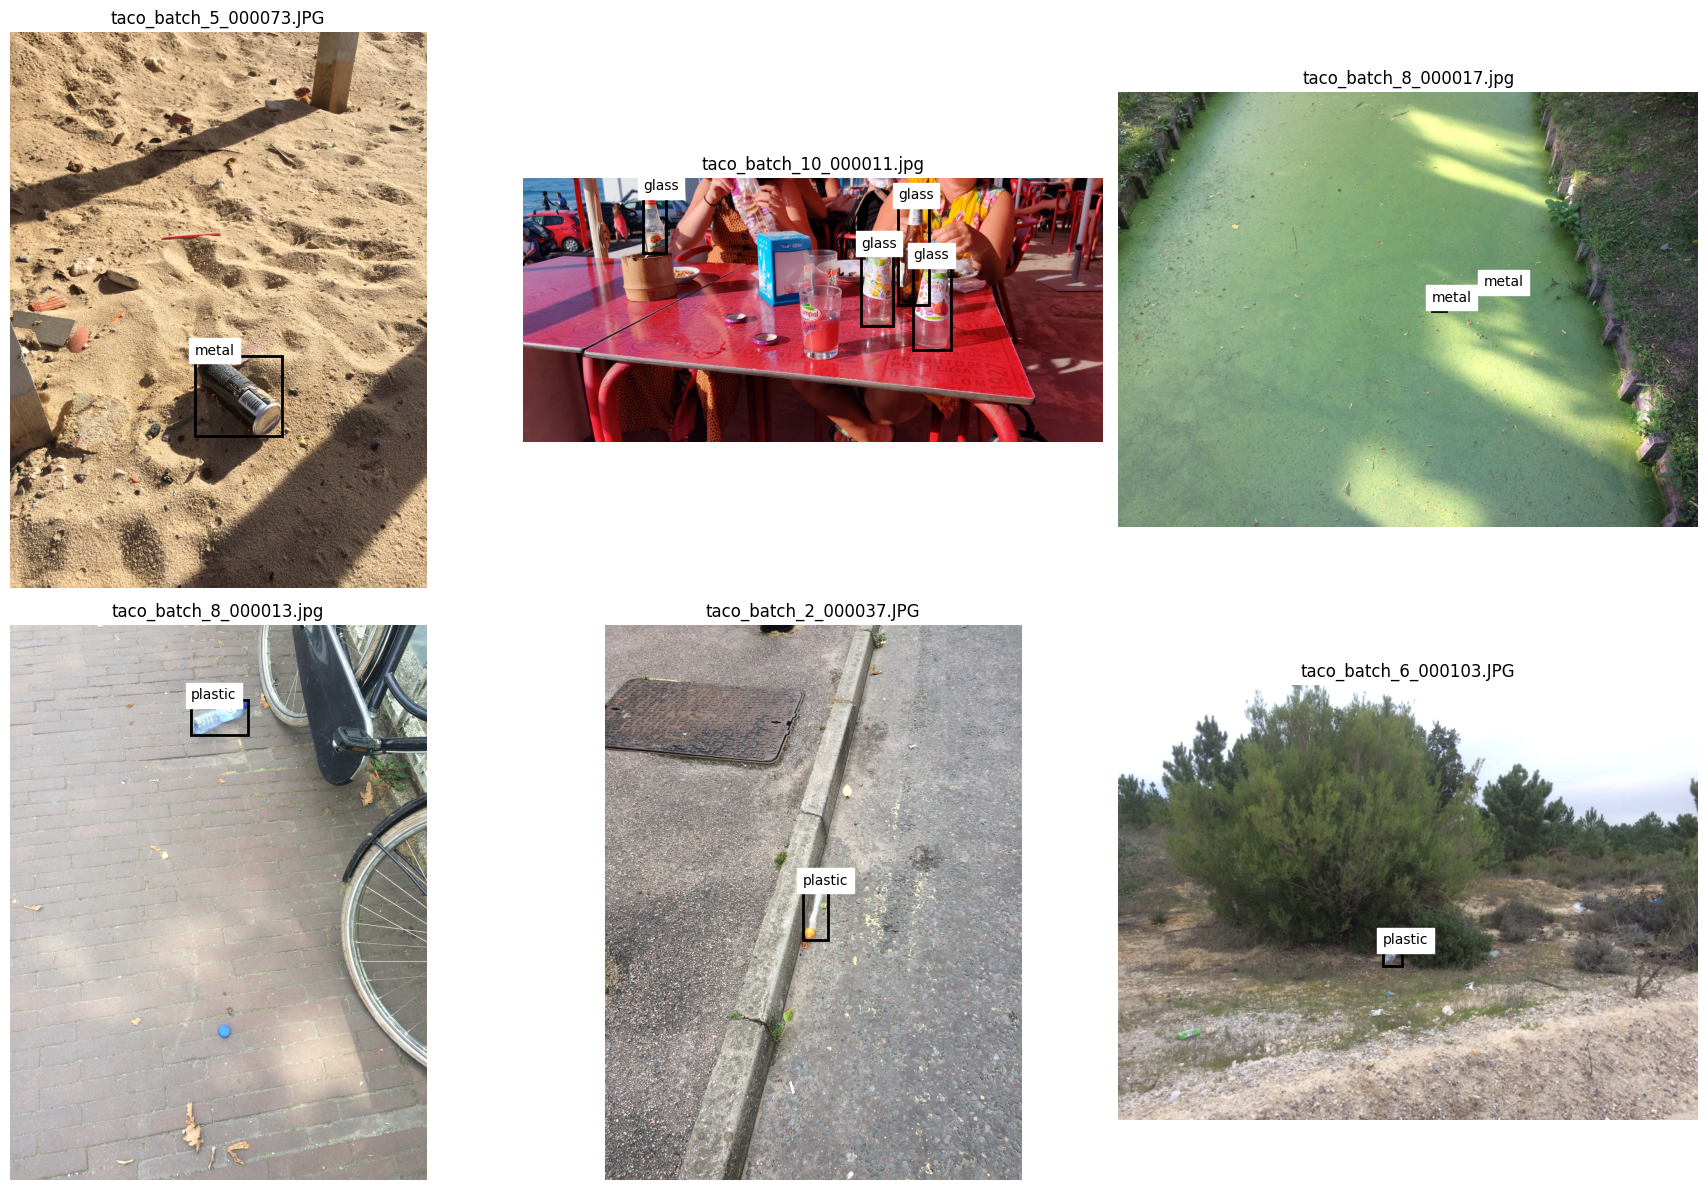

In [56]:
# =========================================================
# VISUAL VERIFICATION OF TACO YOLO DATASET
# =========================================================

import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

sample_images = random.sample(
    image_files,
    min(6, len(image_files))
)

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 12)
)

axes = axes.flatten()

for ax, image_path in zip(axes, sample_images):

    label_path = (
        TACO_FINAL_LABELS
        / f"{image_path.stem}.txt"
    )

    image = Image.open(image_path).convert("RGB")

    image_width, image_height = image.size

    ax.imshow(image)

    # Read YOLO labels
    lines = label_path.read_text().strip().splitlines()

    for line in lines:

        class_id, xc, yc, w, h = map(
            float,
            line.split()
        )

        class_id = int(class_id)

        # ---------------------------------------------
        # YOLO normalized coordinates → pixels
        # ---------------------------------------------

        box_width = w * image_width
        box_height = h * image_height

        x_center = xc * image_width
        y_center = yc * image_height

        x = x_center - box_width / 2
        y = y_center - box_height / 2

        # ---------------------------------------------
        # Draw bounding box
        # ---------------------------------------------

        rect = patches.Rectangle(
            (x, y),
            box_width,
            box_height,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rect)

        # ---------------------------------------------
        # Class name
        # ---------------------------------------------

        ax.text(
            x,
            max(0, y - 5),
            YOLO_CLASSES[class_id],
            fontsize=10,
            backgroundcolor="white"
        )

    ax.set_title(image_path.name)
    ax.axis("off")

# Hide unused axes
for ax in axes[len(sample_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [58]:
# =========================================================
# MERGE EXISTING GARBAGE DATASET + TACO
# =========================================================

import shutil
import random
from pathlib import Path
from collections import Counter

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

PROJECT_ROOT = Path(
    "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8"
)

# Existing dataset
EXISTING_ROOT = PROJECT_ROOT / "data" / "garbage_raw"

# Converted TACO dataset
TACO_FINAL_DIR = PROJECT_ROOT / "data" / "taco_yolo_final"
TACO_FINAL_IMAGES = TACO_FINAL_DIR / "images"
TACO_FINAL_LABELS = TACO_FINAL_DIR / "labels"

# New merged dataset
MERGED_ROOT = PROJECT_ROOT / "data" / "garbage_yolo_merged"

# ---------------------------------------------------------
# Remove old merged dataset if it exists
# ---------------------------------------------------------

if MERGED_ROOT.exists():
    shutil.rmtree(MERGED_ROOT)

for split in ["train", "val", "test"]:
    (MERGED_ROOT / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )

    (MERGED_ROOT / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )

print("Created:", MERGED_ROOT)


# =========================================================
# STEP 1 — Copy existing dataset
# =========================================================

print()
print("=" * 60)
print("COPYING EXISTING DATASET")
print("=" * 60)

# Your original dataset uses "valid"
# Our merged dataset will use standard "val"

EXISTING_SPLITS = {
    "train": "train",
    "valid": "val",
    "test": "test"
}

existing_counts = {}

for old_split, new_split in EXISTING_SPLITS.items():

    src_images = EXISTING_ROOT / old_split / "images"
    src_labels = EXISTING_ROOT / old_split / "labels"

    dst_images = MERGED_ROOT / "images" / new_split
    dst_labels = MERGED_ROOT / "labels" / new_split

    image_files = list(src_images.glob("*"))

    copied = 0

    for image_path in image_files:

        label_path = src_labels / f"{image_path.stem}.txt"

        # Skip anything that is not an image
        if image_path.suffix.lower() not in [
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        ]:
            continue

        if not label_path.exists():
            print(
                "WARNING - missing label:",
                image_path.name
            )
            continue

        shutil.copy2(
            image_path,
            dst_images / image_path.name
        )

        shutil.copy2(
            label_path,
            dst_labels / label_path.name
        )

        copied += 1

    existing_counts[new_split] = copied

    print(
        f"{old_split:6} → {new_split:5} : "
        f"{copied} images"
    )


# =========================================================
# STEP 2 — Split TACO 80/20
# =========================================================

print()
print("=" * 60)
print("SPLITTING TACO")
print("=" * 60)

taco_images = [
    p
    for p in TACO_FINAL_IMAGES.iterdir()
    if p.suffix.lower() in [
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    ]
]

# Fixed seed = reproducible split
random.seed(42)

random.shuffle(taco_images)

split_index = int(
    len(taco_images) * 0.80
)

taco_train = taco_images[:split_index]
taco_val = taco_images[split_index:]

print("Total TACO :", len(taco_images))
print("TACO train :", len(taco_train))
print("TACO val   :", len(taco_val))


# =========================================================
# STEP 3 — Add TACO train/val
# =========================================================

def copy_taco_images(
    image_list,
    split
):

    copied = 0

    for image_path in image_list:

        label_path = (
            TACO_FINAL_LABELS
            / f"{image_path.stem}.txt"
        )

        if not label_path.exists():

            print(
                "WARNING - missing TACO label:",
                image_path.name
            )

            continue

        # TACO filenames already have "taco_" prefix,
        # so they won't collide with the existing dataset.

        shutil.copy2(
            image_path,
            MERGED_ROOT
            / "images"
            / split
            / image_path.name
        )

        shutil.copy2(
            label_path,
            MERGED_ROOT
            / "labels"
            / split
            / label_path.name
        )

        copied += 1

    return copied


taco_train_copied = copy_taco_images(
    taco_train,
    "train"
)

taco_val_copied = copy_taco_images(
    taco_val,
    "val"
)

print()
print("TACO train copied :", taco_train_copied)
print("TACO val copied   :", taco_val_copied)


# =========================================================
# STEP 4 — Final dataset counts
# =========================================================

print()
print("=" * 60)
print("FINAL MERGED DATASET")
print("=" * 60)

for split in ["train", "val", "test"]:

    images_dir = (
        MERGED_ROOT
        / "images"
        / split
    )

    labels_dir = (
        MERGED_ROOT
        / "labels"
        / split
    )

    images = [
        p for p in images_dir.iterdir()
        if p.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        ]
    ]

    labels = list(
        labels_dir.glob("*.txt")
    )

    print(
        f"{split:5} → "
        f"images: {len(images):4} | "
        f"labels: {len(labels):4}"
    )


# =========================================================
# STEP 5 — Check image/label matching
# =========================================================

print()
print("=" * 60)
print("CHECKING IMAGE/LABEL MATCHING")
print("=" * 60)

all_good = True

for split in ["train", "val", "test"]:

    images_dir = MERGED_ROOT / "images" / split
    labels_dir = MERGED_ROOT / "labels" / split

    image_stems = {
        p.stem
        for p in images_dir.iterdir()
        if p.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        ]
    }

    label_stems = {
        p.stem
        for p in labels_dir.glob("*.txt")
    }

    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems

    print()
    print(split)

    print(
        "  Images without labels:",
        len(missing_labels)
    )

    print(
        "  Labels without images:",
        len(missing_images)
    )

    if missing_labels or missing_images:
        all_good = False


# =========================================================
# FINAL
# =========================================================

print()
print("=" * 60)

if all_good:
    print("MERGE SUCCESSFUL")
else:
    print("MERGE HAS PROBLEMS")

print("=" * 60)

print()
print("Merged dataset:")
print(MERGED_ROOT)

Created: /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged

COPYING EXISTING DATASET
train  → train : 0 images
valid  → val   : 0 images
test   → test  : 0 images

SPLITTING TACO
Total TACO : 624
TACO train : 499
TACO val   : 125

TACO train copied : 499
TACO val copied   : 125

FINAL MERGED DATASET
train → images:  499 | labels:  499
val   → images:  125 | labels:  125
test  → images:    0 | labels:    0

CHECKING IMAGE/LABEL MATCHING

train
  Images without labels: 0
  Labels without images: 0

val
  Images without labels: 0
  Labels without images: 0

test
  Images without labels: 0
  Labels without images: 0

MERGE SUCCESSFUL

Merged dataset:
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged


In [59]:
from pathlib import Path

EXISTING_ROOT = PROJECT_ROOT / "data" / "garbage_raw"

print("=" * 60)
print("EXISTING DATASET STRUCTURE")
print("=" * 60)

for path in EXISTING_ROOT.rglob("*"):

    if path.is_dir():
        print(path.relative_to(EXISTING_ROOT))

EXISTING DATASET STRUCTURE
test
train
valid


In [61]:
# =========================================================
# CHECK EXISTING DATASET FILES
# =========================================================

for split in ["train", "valid", "test"]:

    split_path = EXISTING_ROOT / split

    print()
    print("=" * 60)
    print(split.upper())
    print("=" * 60)

    if not split_path.exists():
        print("Folder does not exist")
        continue

    files = list(split_path.iterdir())

    image_files = [
        p for p in files
        if p.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        ]
    ]

    label_files = [
        p for p in files
        if p.suffix.lower() == ".txt"
    ]

    print("Total files :", len(files))
    print("Images      :", len(image_files))
    print("Labels      :", len(label_files))

    print()
    print("First 5 images:")

    for p in image_files[:5]:
        print(" ", p.name)

    print()
    print("First 5 labels:")

    for p in label_files[:5]:
        print(" ", p.name)


TRAIN
Total files : 7325
Images      : 7324
Labels      : 0

First 5 images:
  metal1195_jpg.rf.5e38e478e039d8b07852d000ea54a7ab.jpg
  plastic730_jpg.rf.2fac9f5b84871f40797778442f0a685f.jpg
  cardboard1621_jpg.rf.7ac85ee81286c6eb1befdabae10cbc08.jpg
  glass1540_jpg.rf.043d922c8d8dc63c9a22a74b3f8d239f.jpg
  cardboard1273_jpg.rf.1b816fc00809d398fc3b9dbca072cc8e.jpg

First 5 labels:

VALID
Total files : 2099
Images      : 2098
Labels      : 0

First 5 images:
  cardboard1766_jpg.rf.f9f5e007c709eab8019baf4900423e76.jpg
  cardboard1599_jpg.rf.d010a811183b669bbcdf593a7e30fa26.jpg
  metal695_jpg.rf.425d54cec7824e2a69a6292201644ca1.jpg
  biodegradable1902_jpeg.rf.ca9e3992f91872cafd567793dc7f2f9f.jpg
  biodegradable1049_jpg.rf.624a77d25fb297c5361fc8cd307e32a6.jpg

First 5 labels:

TEST
Total files : 1043
Images      : 1042
Labels      : 0

First 5 images:
  paper842_jpg.rf.9ab4cc19a05165a8041d37a0ce80074a.jpg
  paper1938_jpg.rf.4dafc6f09d1fb64c90457f8b28d1acb0.jpg
  plastic370_jpg.rf.3b5d564fc

In [64]:
# =========================================================
# CONVERT EXISTING GARBAGE DATASET
# COCO → YOLO
# =========================================================

import json
import shutil
from pathlib import Path
from collections import Counter

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

PROJECT_ROOT = Path(
    "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8"
)

EXISTING_ROOT = (
    PROJECT_ROOT / "data" / "garbage_raw"
)

EXISTING_YOLO_ROOT = (
    PROJECT_ROOT / "data" / "garbage_existing_yolo"
)

# ---------------------------------------------------------
# Fresh output directory
# ---------------------------------------------------------

if EXISTING_YOLO_ROOT.exists():
    shutil.rmtree(EXISTING_YOLO_ROOT)

for split in ["train", "val", "test"]:

    (
        EXISTING_YOLO_ROOT
        / "images"
        / split
    ).mkdir(
        parents=True,
        exist_ok=True
    )

    (
        EXISTING_YOLO_ROOT
        / "labels"
        / split
    ).mkdir(
        parents=True,
        exist_ok=True
    )

print("Created:")
print(EXISTING_YOLO_ROOT)


# =========================================================
# COCO → YOLO conversion function
# =========================================================

def coco_bbox_to_yolo(
    bbox,
    image_width,
    image_height
):

    x, y, w, h = bbox

    x_center = (
        x + w / 2
    ) / image_width

    y_center = (
        y + h / 2
    ) / image_height

    width = w / image_width
    height = h / image_height

    return (
        x_center,
        y_center,
        width,
        height
    )


# =========================================================
# Convert each split
# =========================================================

SPLIT_MAPPING = {
    "train": "train",
    "valid": "val",
    "test": "test"
}

total_images = 0
total_annotations = 0

global_class_counts = Counter()


for old_split, new_split in SPLIT_MAPPING.items():

    print()
    print("=" * 60)
    print(f"CONVERTING {old_split.upper()}")
    print("=" * 60)

    split_root = (
        EXISTING_ROOT / old_split
    )

    annotation_file = (
        split_root
        / "_annotations.coco.json"
    )

    # -----------------------------------------------------
    # Load COCO JSON
    # -----------------------------------------------------

    with open(
        annotation_file,
        "r"
    ) as f:

        coco_data = json.load(f)

    # -----------------------------------------------------
    # Image lookup
    # -----------------------------------------------------

    image_lookup = {
        image["id"]: image
        for image in coco_data["images"]
    }

    # -----------------------------------------------------
    # Group annotations by image
    # -----------------------------------------------------

    annotations_by_image = {}

    for ann in coco_data["annotations"]:

        image_id = ann["image_id"]

        if image_id not in annotations_by_image:
            annotations_by_image[image_id] = []

        annotations_by_image[
            image_id
        ].append(ann)

    split_images = 0
    split_annotations = 0
    split_class_counts = Counter()

    # -----------------------------------------------------
    # Process images
    # -----------------------------------------------------

    for image_id, image_info in image_lookup.items():

        file_name = image_info["file_name"]

        source_image = (
            split_root / file_name
        )

        # -------------------------------------------------
        # Make sure image exists
        # -------------------------------------------------

        if not source_image.exists():

            print(
                "WARNING - missing image:",
                file_name
            )

            continue

        # -------------------------------------------------
        # Copy image
        # -------------------------------------------------

        destination_image = (
            EXISTING_YOLO_ROOT
            / "images"
            / new_split
            / source_image.name
        )

        shutil.copy2(
            source_image,
            destination_image
        )

        # -------------------------------------------------
        # Create YOLO label
        # -------------------------------------------------

        label_file = (
            EXISTING_YOLO_ROOT
            / "labels"
            / new_split
            / f"{source_image.stem}.txt"
        )

        lines = []

        image_width = image_info["width"]
        image_height = image_info["height"]

        annotations = annotations_by_image.get(
            image_id,
            []
        )

        for ann in annotations:

            class_id = ann["category_id"]

            # Existing classes are already
            # 0-5 and match YOLO_CLASSES

            x_center, y_center, width, height = (
                coco_bbox_to_yolo(
                    ann["bbox"],
                    image_width,
                    image_height
                )
            )

            # -------------------------------------------------
            # Safety check
            # -------------------------------------------------

            if not (
                0 <= x_center <= 1
                and 0 <= y_center <= 1
                and 0 < width <= 1
                and 0 < height <= 1
            ):

                print(
                    "WARNING - invalid bbox:",
                    file_name,
                    ann["bbox"]
                )

                continue

            lines.append(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{width:.6f} "
                f"{height:.6f}"
            )

            split_annotations += 1
            total_annotations += 1

            split_class_counts[class_id] += 1
            global_class_counts[class_id] += 1

        # -------------------------------------------------
        # Save label
        # -------------------------------------------------

        label_file.write_text(
            "\n".join(lines) + "\n"
        )

        split_images += 1
        total_images += 1

    # -----------------------------------------------------
    # Split result
    # -----------------------------------------------------

    print(
        "Images converted     :",
        split_images
    )

    print(
        "Annotations converted:",
        split_annotations
    )

    print()
    print("Class distribution:")

    for class_id, class_name in enumerate(
        YOLO_CLASSES
    ):

        print(
            f"{class_id}: "
            f"{class_name:<15} "
            f"{split_class_counts[class_id]}"
        )


# =========================================================
# FINAL RESULT
# =========================================================

print()
print("=" * 60)
print("EXISTING DATASET COCO → YOLO COMPLETE")
print("=" * 60)

print(
    "Total images      :",
    total_images
)

print(
    "Total annotations :",
    total_annotations
)

print()
print("Global class distribution:")

for class_id, class_name in enumerate(
    YOLO_CLASSES
):

    print(
        f"{class_id}: "
        f"{class_name:<15} "
        f"{global_class_counts[class_id]}"
    )

print()
print(
    "Output:",
    EXISTING_YOLO_ROOT
)

Created:
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_existing_yolo

CONVERTING TRAIN
WARNING - invalid bbox: biodegradable366_jpg.rf.09e6cd29dee38feb3b4df80653e5fb0f.jpg [174, 163, 20, 0]
WARNING - invalid bbox: biodegradable421_jpg.rf.0d8bc76989848c2d9173e3c49c133867.jpg [348, 238, 0, 3]
WARNING - invalid bbox: biodegradable1998_jpeg.rf.17921ee65cee3e00f10a24d639dff35b.jpg [186, 198, 26, 0]
WARNING - invalid bbox: paper1805_jpeg.rf.3cbe8e415d51c085ff0165a12cea5880.jpg [128, 61, 0, 2]
WARNING - invalid bbox: biodegradable419_jpg.rf.3cb6ccbe84af9a0d1a083252e479def4.jpg [200, 65, 2, 0]
WARNING - invalid bbox: biodegradable1740_jpg.rf.5f00e1157464c17341765a596a148298.jpg [107, 225, 0, 18]
WARNING - invalid bbox: biodegradable1465_jpg.rf.6554b314de4df3aed0117f0283e9df7f.jpg [169, 373, 5, 0]
WARNING - invalid bbox: cardboard895_jpg.rf.9fe0d5e9a4d71705fa33323a01dcc534.jpg [69, 86, 0, 2]
WARNING - invalid bbox: paper787_jpg.rf.a776cf355b31868a4cfda6ff51850600.jpg [3

In [66]:
# =========================================================
# MERGE EXISTING DATASET + TACO
# =========================================================

from pathlib import Path
import shutil
import random

PROJECT_ROOT = Path(
    "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8"
)

EXISTING_YOLO_ROOT = (
    PROJECT_ROOT
    / "data"
    / "garbage_existing_yolo"
)

TACO_YOLO_ROOT = (
    PROJECT_ROOT
    / "data"
    / "taco_yolo_final"
)

MERGED_ROOT = (
    PROJECT_ROOT
    / "data"
    / "garbage_yolo_merged"
)

# ---------------------------------------------------------
# 1. Remove old incorrect merge
# ---------------------------------------------------------

if MERGED_ROOT.exists():
    shutil.rmtree(MERGED_ROOT)

# ---------------------------------------------------------
# 2. Create folders
# ---------------------------------------------------------

for split in ["train", "val", "test"]:
    (MERGED_ROOT / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )

    (MERGED_ROOT / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )

print("Created:", MERGED_ROOT)

# ---------------------------------------------------------
# 3. Copy EXISTING dataset
# ---------------------------------------------------------

print()
print("=" * 60)
print("COPYING EXISTING DATASET")
print("=" * 60)

existing_counts = {}

for split in ["train", "val", "test"]:

    src_images = (
        EXISTING_YOLO_ROOT
        / "images"
        / split
    )

    src_labels = (
        EXISTING_YOLO_ROOT
        / "labels"
        / split
    )

    dst_images = (
        MERGED_ROOT
        / "images"
        / split
    )

    dst_labels = (
        MERGED_ROOT
        / "labels"
        / split
    )

    image_files = [
        p for p in src_images.iterdir()
        if p.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        ]
    ]

    for image_file in image_files:
        shutil.copy2(
            image_file,
            dst_images / image_file.name
        )

    for label_file in src_labels.glob("*.txt"):
        shutil.copy2(
            label_file,
            dst_labels / label_file.name
        )

    existing_counts[split] = len(image_files)

    print(
        f"{split.upper():5s}: "
        f"{len(image_files)} images copied"
    )

# ---------------------------------------------------------
# 4. Get TACO images
# ---------------------------------------------------------

taco_images_dir = (
    TACO_YOLO_ROOT
    / "images"
)

taco_labels_dir = (
    TACO_YOLO_ROOT
    / "labels"
)

taco_images = [
    p for p in taco_images_dir.iterdir()
    if p.suffix.lower() in [
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    ]
]

# ---------------------------------------------------------
# 5. Deterministic TACO split
# ---------------------------------------------------------

random.seed(42)

random.shuffle(taco_images)

taco_train = taco_images[:499]
taco_val = taco_images[499:]

print()
print("=" * 60)
print("TACO SPLIT")
print("=" * 60)

print("Total TACO images :", len(taco_images))
print("TACO train        :", len(taco_train))
print("TACO val          :", len(taco_val))

# ---------------------------------------------------------
# 6. Copy TACO into merged dataset
# ---------------------------------------------------------

def copy_taco_images(image_list, split):

    dst_images = (
        MERGED_ROOT
        / "images"
        / split
    )

    dst_labels = (
        MERGED_ROOT
        / "labels"
        / split
    )

    copied = 0
    annotations = 0

    for image_file in image_list:

        label_file = (
            taco_labels_dir
            / f"{image_file.stem}.txt"
        )

        if not label_file.exists():
            raise FileNotFoundError(
                f"Missing label: {label_file}"
            )

        # Check filename collision
        dst_image = dst_images / image_file.name
        dst_label = dst_labels / label_file.name

        if dst_image.exists():
            raise RuntimeError(
                f"IMAGE NAME COLLISION: {image_file.name}"
            )

        if dst_label.exists():
            raise RuntimeError(
                f"LABEL NAME COLLISION: {label_file.name}"
            )

        shutil.copy2(
            image_file,
            dst_image
        )

        shutil.copy2(
            label_file,
            dst_label
        )

        copied += 1

        lines = (
            label_file
            .read_text()
            .strip()
            .splitlines()
        )

        annotations += len(
            [line for line in lines if line.strip()]
        )

    return copied, annotations


train_copied, train_annotations = copy_taco_images(
    taco_train,
    "train"
)

val_copied, val_annotations = copy_taco_images(
    taco_val,
    "val"
)

print()
print("=" * 60)
print("TACO COPIED")
print("=" * 60)

print(
    "Train:",
    train_copied,
    "images /",
    train_annotations,
    "annotations"
)

print(
    "Val  :",
    val_copied,
    "images /",
    val_annotations,
    "annotations"
)

# ---------------------------------------------------------
# 7. Create data.yaml
# ---------------------------------------------------------

yaml_content = f"""path: {MERGED_ROOT}
train: images/train
val: images/val
test: images/test

names:
  0: biodegradable
  1: cardboard
  2: glass
  3: metal
  4: paper
  5: plastic
"""

yaml_path = MERGED_ROOT / "data.yaml"

yaml_path.write_text(yaml_content)

# ---------------------------------------------------------
# 8. Final counts
# ---------------------------------------------------------

print()
print("=" * 60)
print("FINAL MERGED DATASET")
print("=" * 60)

for split in ["train", "val", "test"]:

    images_dir = (
        MERGED_ROOT
        / "images"
        / split
    )

    labels_dir = (
        MERGED_ROOT
        / "labels"
        / split
    )

    images = [
        p for p in images_dir.iterdir()
        if p.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        ]
    ]

    labels = list(
        labels_dir.glob("*.txt")
    )

    print(
        f"{split.upper():5s}: "
        f"{len(images)} images | "
        f"{len(labels)} labels"
    )

print()
print("data.yaml:")
print(yaml_path)

print()
print("✅ MERGE COMPLETE")

Created: /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged

COPYING EXISTING DATASET
TRAIN: 7324 images copied
VAL  : 2098 images copied
TEST : 1042 images copied

TACO SPLIT
Total TACO images : 624
TACO train        : 499
TACO val          : 125

TACO COPIED
Train: 499 images / 769 annotations
Val  : 125 images / 213 annotations

FINAL MERGED DATASET
TRAIN: 7823 images | 7823 labels
VAL  : 2223 images | 2223 labels
TEST : 1042 images | 1042 labels

data.yaml:
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged/data.yaml

✅ MERGE COMPLETE


In [67]:
# =========================================================
# FINAL MERGED DATASET VERIFICATION
# =========================================================

from pathlib import Path
from collections import Counter

MERGED_ROOT = Path(
    "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8"
) / "data" / "garbage_yolo_merged"

YOLO_CLASSES = [
    "biodegradable",
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic"
]

valid_extensions = [
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
]

class_counts = Counter()
invalid_labels = []

print("=" * 60)
print("FINAL MERGED DATASET VERIFICATION")
print("=" * 60)

for split in ["train", "val", "test"]:

    images_dir = MERGED_ROOT / "images" / split
    labels_dir = MERGED_ROOT / "labels" / split

    image_files = [
        p for p in images_dir.iterdir()
        if p.suffix.lower() in valid_extensions
    ]

    label_files = list(labels_dir.glob("*.txt"))

    image_stems = {p.stem for p in image_files}
    label_stems = {p.stem for p in label_files}

    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems

    split_class_counts = Counter()

    for label_file in label_files:

        lines = (
            label_file.read_text()
            .strip()
            .splitlines()
        )

        for line_number, line in enumerate(lines, 1):

            if not line.strip():
                continue

            parts = line.split()

            if len(parts) != 5:
                invalid_labels.append(
                    (
                        split,
                        label_file.name,
                        line_number,
                        line
                    )
                )
                continue

            try:
                class_id = int(parts[0])

                x = float(parts[1])
                y = float(parts[2])
                w = float(parts[3])
                h = float(parts[4])

            except ValueError:
                invalid_labels.append(
                    (
                        split,
                        label_file.name,
                        line_number,
                        line
                    )
                )
                continue

            # Class ID check
            if not (0 <= class_id < len(YOLO_CLASSES)):
                invalid_labels.append(
                    (
                        split,
                        label_file.name,
                        line_number,
                        line
                    )
                )
                continue

            # Bounding box check
            if not (
                0 <= x <= 1
                and 0 <= y <= 1
                and 0 < w <= 1
                and 0 < h <= 1
            ):
                invalid_labels.append(
                    (
                        split,
                        label_file.name,
                        line_number,
                        line
                    )
                )
                continue

            split_class_counts[class_id] += 1
            class_counts[class_id] += 1

    print()
    print(split.upper())
    print("-" * 60)

    print("Images              :", len(image_files))
    print("Labels              :", len(label_files))
    print("Images without label :", len(missing_labels))
    print("Labels without image :", len(missing_images))
    print("Annotations         :", sum(split_class_counts.values()))

    print("Class distribution:")

    for class_id, class_name in enumerate(YOLO_CLASSES):
        print(
            f"  {class_id}: "
            f"{class_name:<15} "
            f"{split_class_counts[class_id]}"
        )

print()
print("=" * 60)
print("GLOBAL CLASS DISTRIBUTION")
print("=" * 60)

for class_id, class_name in enumerate(YOLO_CLASSES):
    print(
        f"{class_id}: "
        f"{class_name:<15} "
        f"{class_counts[class_id]}"
    )

print()
print("=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("Invalid YOLO label lines:", len(invalid_labels))

if invalid_labels:
    print()
    print("First 10 invalid labels:")
    for item in invalid_labels[:10]:
        print(item)
else:
    print("✅ All YOLO labels are valid.")

print()
print("🎉 MERGED DATASET VERIFICATION COMPLETE")

FINAL MERGED DATASET VERIFICATION

TRAIN
------------------------------------------------------------
Images              : 7823
Labels              : 7823
Images without label : 0
Labels without image : 0
Annotations         : 52370
Class distribution:
  0: biodegradable   31721
  1: cardboard       3501
  2: glass           5509
  3: metal           4113
  4: paper           3095
  5: plastic         4431

VAL
------------------------------------------------------------
Images              : 2223
Labels              : 2223
Images without label : 0
Labels without image : 0
Annotations         : 19123
Class distribution:
  0: biodegradable   13633
  1: cardboard       1332
  2: glass           2404
  3: metal           1424
  4: paper           66
  5: plastic         264

TEST
------------------------------------------------------------
Images              : 1042
Labels              : 1042
Images without label : 0
Labels without image : 0
Annotations         : 3562
Class distribution:

In [69]:
from ultralytics import YOLO
import torch

DATA_YAML = (
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "data/garbage_yolo_merged/data.yaml"
)

print("GPU:", torch.cuda.get_device_name(0))

model = YOLO("yolov8n.pt")

results = model.train(
    data=DATA_YAML,

    # Training
    epochs=50,
    imgsz=640,

    # RTX A5500
    batch=32,
    device=0,
    workers=8,

    # Reproducibility
    seed=42,

    # Save/checkpoints
    project="/home/kumari-shikha/"
            "Garbage-Waste-Object-Detection-YOLOv8/"
            "runs",
    name="yolov8n_merged_50ep",

    # Useful training settings
    pretrained=True,
    patience=15,
    cache=False,

    # Save results
    save=True,
    plots=True
)

GPU: NVIDIA RTX A5500
New https://pypi.org/project/ultralytics/8.4.164 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.153 🚀 Python-3.10.12 torch-2.14.0+cu130 CUDA:0 (NVIDIA RTX A5500, 24103MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_w

In [70]:
from ultralytics import YOLO

MODEL_PATH = (
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "runs/yolov8n_merged_50ep/weights/best.pt"
)

DATA_YAML = (
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "data/garbage_yolo_merged/data.yaml"
)

model = YOLO(MODEL_PATH)

metrics = model.val(
    data=DATA_YAML,
    split="val",
    imgsz=640,
    batch=32,
    device=0
)

print("mAP50    :", metrics.box.map50)
print("mAP50-95 :", metrics.box.map)

Ultralytics 8.4.153 🚀 Python-3.10.12 torch-2.14.0+cu130 CUDA:0 (NVIDIA RTX A5500, 24103MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1728.2±631.5 MB/s, size: 20.8 KB)
val: Scanning /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged/labels/val.cache... 2223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2223/2223 518.0Mit/s 0.0s
WARNING ⚠️ Dataset images contain up to 311 objects (val=311), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=311 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 70/70 7.6it/s 9.2s0.1ss
                   all       2223      19123      0.594      0.468      0.518      0.354
         biodeg

In [72]:
print()
print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print("mAP50    :", test_metrics.box.map50)
print("mAP50-95 :", test_metrics.box.map)

print()
print("Per-class mAP50:")
print("(Classes without test instances are shown as N/A)")

class_names = [
    "biodegradable",
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic"
]

# Classes that actually have test instances
test_instances = [49, 20, 0, 533, 1375, 1585]

ap50 = test_metrics.box.ap50

valid_metric_index = 0

for class_id, class_name in enumerate(class_names):

    if test_instances[class_id] == 0:
        print(
            f"{class_id}: "
            f"{class_name:<15} N/A "
            f"(0 test instances)"
        )
    else:
        print(
            f"{class_id}: "
            f"{class_name:<15} "
            f"{ap50[valid_metric_index]:.4f}"
        )
        valid_metric_index += 1


FINAL TEST RESULTS
mAP50    : 0.43067401764680807
mAP50-95 : 0.3209094097225313

Per-class mAP50:
(Classes without test instances are shown as N/A)
0: biodegradable   0.0837
1: cardboard       0.1315
2: glass           N/A (0 test instances)
3: metal           0.6799
4: paper           0.6003
5: plastic         0.6580


Selected test images:
plastic1063_jpg.rf.6b3c8bf2c5e544548b2bee978b6ddc42.jpg
metal4_jpg.rf.95bf1c428ead5f8f591d5597fd3f81a6.jpg
metal1155_jpg.rf.e3d60e3023bb416f5f2e8c0675abd84c.jpg
metal372_jpg.rf.7671d4d39eb45c276d5442b2c0f892c5.jpg
paper305_jpg.rf.fe50060e4ff619ccfca8ece48dd09355.jpg
paper767_jpg.rf.70ce84042d9f09370d1a3a7739196545.jpg

0: 640x640 11 plastics, 1.2ms
1: 640x640 1 metal, 1 plastic, 1.2ms
2: 640x640 3 biodegradables, 5 metals, 1.2ms
3: 640x640 1 metal, 1.2ms
4: 640x640 2 papers, 1.2ms
5: 640x640 1 paper, 1.2ms
Speed: 0.9ms preprocess, 1.2ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


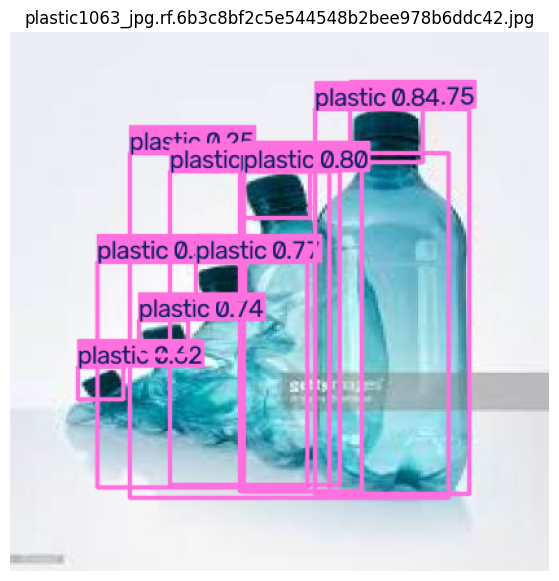

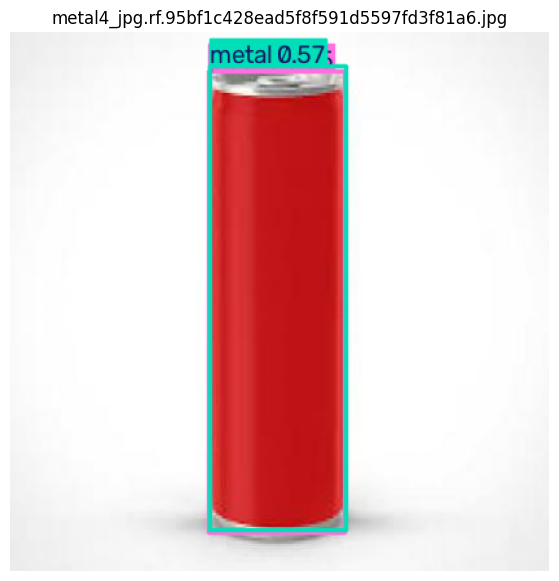

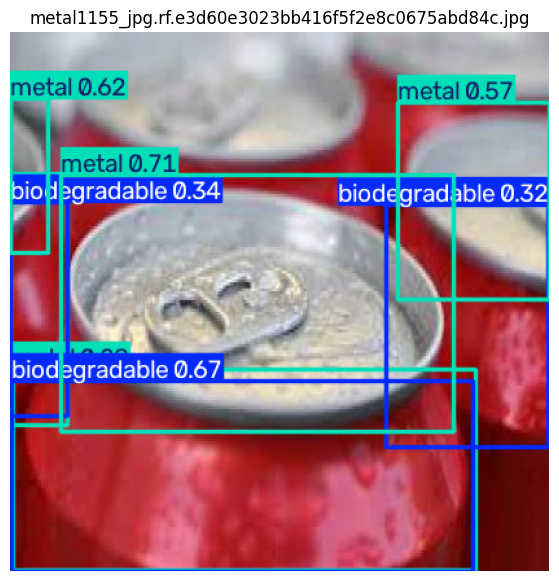

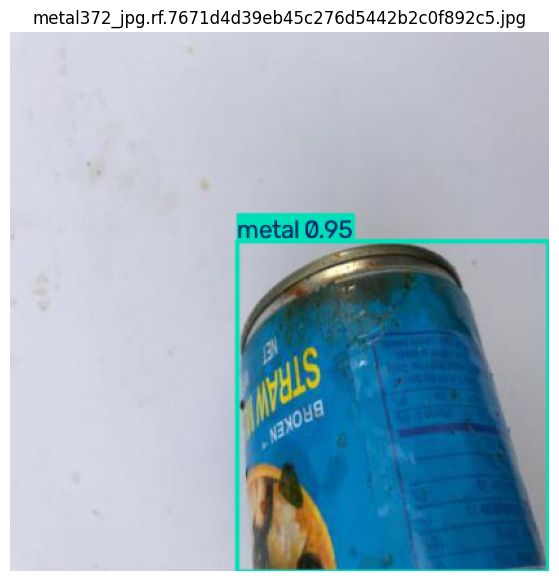

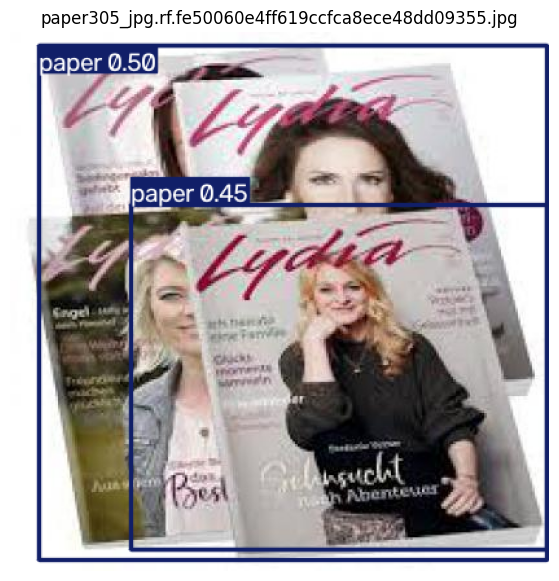

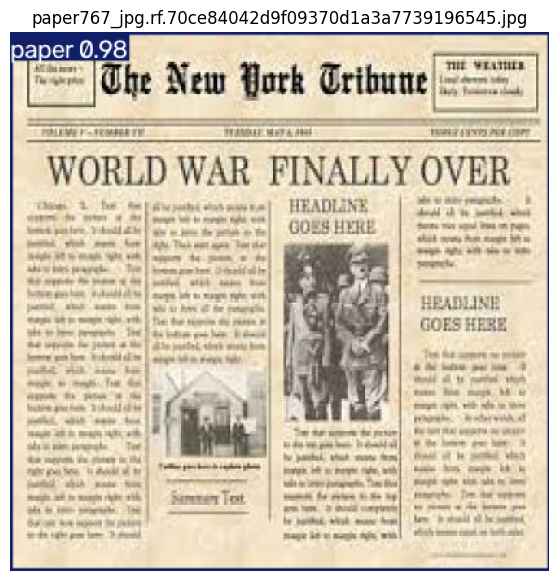

In [73]:
from ultralytics import YOLO
from pathlib import Path
import random
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

PROJECT_ROOT = Path(
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "runs"
    / "yolov8n_merged_50ep"
    / "weights"
    / "best.pt"
)

TEST_IMAGES = (
    PROJECT_ROOT
    / "data"
    / "garbage_yolo_merged"
    / "images"
    / "test"
)

# ---------------------------------------------------------
# Load model
# ---------------------------------------------------------

model = YOLO(MODEL_PATH)

# ---------------------------------------------------------
# Select random test images
# ---------------------------------------------------------

random.seed(42)

image_files = [
    p for p in TEST_IMAGES.iterdir()
    if p.suffix.lower() in [
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    ]
]

selected_images = random.sample(
    image_files,
    min(6, len(image_files))
)

print("Selected test images:")

for image in selected_images:
    print(image.name)

# ---------------------------------------------------------
# Run predictions
# ---------------------------------------------------------

results = model.predict(
    source=[str(p) for p in selected_images],
    imgsz=640,
    conf=0.25,
    device=0,
    save=False
)

# ---------------------------------------------------------
# Display predictions
# ---------------------------------------------------------

for image_path, result in zip(
    selected_images,
    results
):

    annotated = result.plot()

    plt.figure(figsize=(10, 7))
    plt.imshow(annotated[:, :, ::-1])
    plt.title(image_path.name)
    plt.axis("off")
    plt.show()

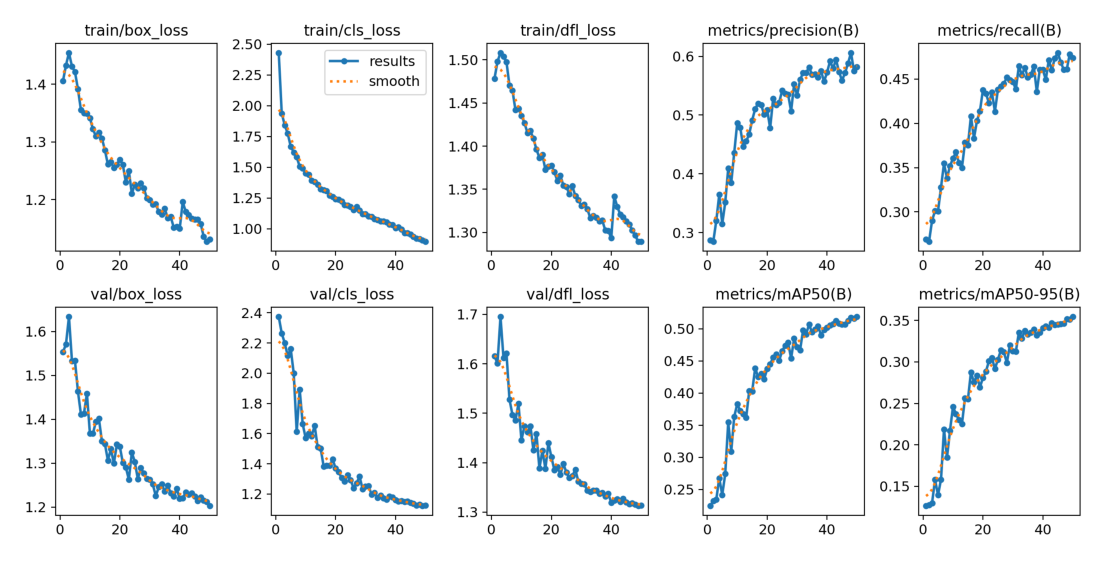

In [74]:
from PIL import Image
import matplotlib.pyplot as plt

results_path = (
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "runs/yolov8n_merged_50ep/"
    "results.png"
)

img = Image.open(results_path)

plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [75]:
from ultralytics import YOLO

MODEL_PATH = (
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "runs/yolov8n_merged_50ep/"
    "weights/best.pt"
)

DATA_YAML = (
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "data/garbage_yolo_merged/data.yaml"
)

model = YOLO(MODEL_PATH)

results = model.train(
    data=DATA_YAML,
    epochs=100,
    imgsz=640,
    batch=32,
    device=0,
    workers=8,
    seed=42,

    patience=20,

    project=(
        "/home/kumari-shikha/"
        "Garbage-Waste-Object-Detection-YOLOv8/"
        "runs"
    ),
    name="yolov8n_merged_100ep",

    pretrained=True,
    cache=False,
    save=True,
    plots=True
)

New https://pypi.org/project/ultralytics/8.4.164 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.153 🚀 Python-3.10.12 torch-2.14.0+cu130 CUDA:0 (NVIDIA RTX A5500, 24103MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, 

In [76]:
from ultralytics import YOLO

PROJECT_ROOT = "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8"

MODEL_PATH = (
    f"{PROJECT_ROOT}/runs/"
    "yolov8n_merged_100ep/"
    "weights/best.pt"
)

DATA_YAML = (
    f"{PROJECT_ROOT}/data/"
    "garbage_yolo_merged/data.yaml"
)

model = YOLO(MODEL_PATH)

print("Model loaded:", MODEL_PATH)

Model loaded: /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/runs/yolov8n_merged_100ep/weights/best.pt


In [77]:
val_metrics = model.val(
    data=DATA_YAML,
    split="val",
    imgsz=640,
    batch=32,
    device=0,
    plots=True
)

print()
print("=" * 60)
print("100-EPOCH VALIDATION RESULTS")
print("=" * 60)

print(f"mAP50    : {val_metrics.box.map50:.4f}")
print(f"mAP50-95 : {val_metrics.box.map:.4f}")

Ultralytics 8.4.153 🚀 Python-3.10.12 torch-2.14.0+cu130 CUDA:0 (NVIDIA RTX A5500, 24103MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1636.1±819.1 MB/s, size: 17.6 KB)
val: Scanning /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged/labels/val.cache... 2223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2223/2223 444.0Mit/s 0.0s
WARNING ⚠️ Dataset images contain up to 311 objects (val=311), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=311 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 70/70 7.9it/s 8.9s<0.1s
                   all       2223      19123      0.592      0.499      0.526      0.364
         biodeg

In [78]:
print()
print("PER-CLASS RESULTS")
print("=" * 60)

for class_id, class_name in model.names.items():

    print(
        f"{class_id}: "
        f"{class_name:<15} "
        f"mAP50={val_metrics.box.ap50[class_id]:.4f} "
        f"mAP50-95={val_metrics.box.ap[class_id]:.4f}"
    )


PER-CLASS RESULTS
0: biodegradable   mAP50=0.6167 mAP50-95=0.3507
1: cardboard       mAP50=0.5949 mAP50-95=0.4441
2: glass           mAP50=0.8032 mAP50-95=0.5952
3: metal           mAP50=0.6747 mAP50-95=0.4651
4: paper           mAP50=0.0698 mAP50-95=0.0543
5: plastic         mAP50=0.3955 mAP50-95=0.2715


In [79]:
test_metrics_100 = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=32,
    device=0,
    plots=True
)

print()
print("=" * 60)
print("100-EPOCH FINAL TEST RESULTS")
print("=" * 60)

print(f"mAP50    : {test_metrics_100.box.map50:.4f}")
print(f"mAP50-95 : {test_metrics_100.box.map:.4f}")

Ultralytics 8.4.153 🚀 Python-3.10.12 torch-2.14.0+cu130 CUDA:0 (NVIDIA RTX A5500, 24103MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1709.3±304.7 MB/s, size: 22.1 KB)
val: Scanning /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged/labels/test.cache... 1042 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1042/1042 257.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 8.8it/s 3.7s<0.2s
                   all       1042       3562      0.551      0.437      0.441      0.329
         biodegradable          8         49      0.178      0.224     0.0985     0.0442
             cardboard         11         20       0.13        0.3      0.154       0.13
                 metal        172        533      0.826      0.645      0.679      0.558
                 paper        515       1375       0.83

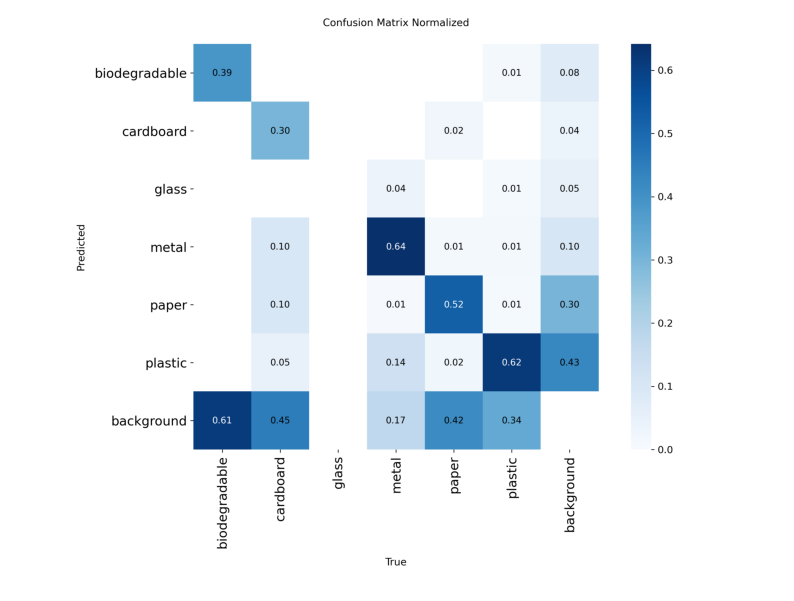

In [80]:
from PIL import Image
import matplotlib.pyplot as plt

cm_path = (
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "runs/detect/val-4/"
    "confusion_matrix_normalized.png"
)

img = Image.open(cm_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [85]:
from pathlib import Path

DATA_YAML = Path(
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "data/garbage_yolo_merged/data.yaml"
)

print(DATA_YAML.read_text())

path: /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged
train: images/train
val: images/val
test: images/test

names:
  0: biodegradable
  1: cardboard
  2: glass
  3: metal
  4: paper
  5: plastic



In [86]:
MERGED_ROOT = DATA_YAML.parent

print("\nDataset contents:")
for p in MERGED_ROOT.iterdir():
    print(
        f"{p.name:<20} "
        f"{'DIR' if p.is_dir() else 'FILE'}"
    )


Dataset contents:
labels               DIR
data.yaml            FILE
images               DIR


In [88]:
source=f"{PROJECT_ROOT}/data/garbage_yolo_merged/test/images"

In [89]:
from ultralytics import YOLO

model = YOLO(MODEL_PATH)

TEST_IMAGES = (
    f"{PROJECT_ROOT}/data/garbage_yolo_merged/images/test"
)

results = model.predict(
    source=TEST_IMAGES,
    imgsz=640,
    conf=0.25,
    save=True,
    device=0,
    max_det=311
)

print("Prediction visualization complete.")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1042 /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged/images/test/metal1000_jpg.rf.f972491130c59d3bff7e97b22e8e2980.jpg: 640x640 1 metal, 3.0ms
image 2/1042 /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yolo_merged/images/test/metal1005_jpg.rf.d736ab336e8fa92ce57727666e624259.jpg: 640x640 1 metal, 2.5ms
image 3/1042 /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_yol

In [90]:
from pathlib import Path

PRED_DIR = Path(
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "runs/detect/predict"
)

print("Exists:", PRED_DIR.exists())

if PRED_DIR.exists():
    images = list(PRED_DIR.glob("*.jpg")) + list(PRED_DIR.glob("*.jpeg"))

    print("Prediction images:", len(images))

    for img in images[:10]:
        print(img.name)

Exists: True
Prediction images: 1042
paper842_jpg.rf.9ab4cc19a05165a8041d37a0ce80074a.jpg
paper1938_jpg.rf.4dafc6f09d1fb64c90457f8b28d1acb0.jpg
plastic370_jpg.rf.3b5d564fca5802e0a785363ad3aa5905.jpg
metal373_jpg.rf.955bce51f0681c36f60bb2fa81b1552d.jpg
plastic655_jpg.rf.2a04ba88a1aceed34553f7ca61d8d123.jpg
paper1092_jpg.rf.c7360b4975c0acf55d35948948db1628.jpg
paper2301_jpg.rf.a1055e036036a3ce2a310e121919b9ef.jpg
plastic916_jpg.rf.72f22345a6c9ddc30707994447c6d1f5.jpg
paper132_jpg.rf.8e1c63baa489b5937ebf3e5079eaa54e.jpg
paper1741_jpeg.rf.4ec3f1538ca91a5e8ddff3d15b183f52.jpg


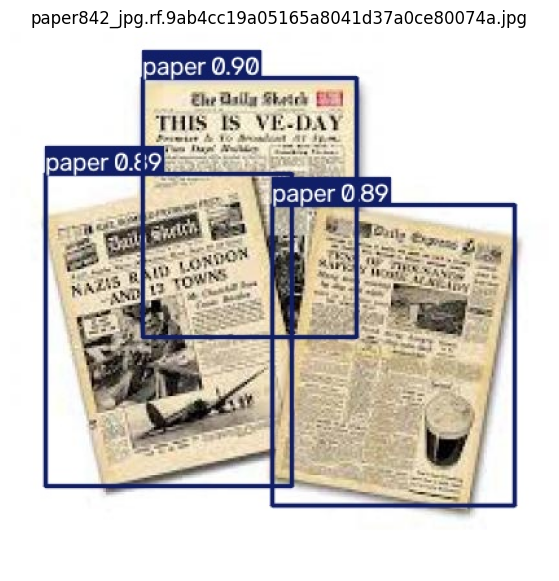

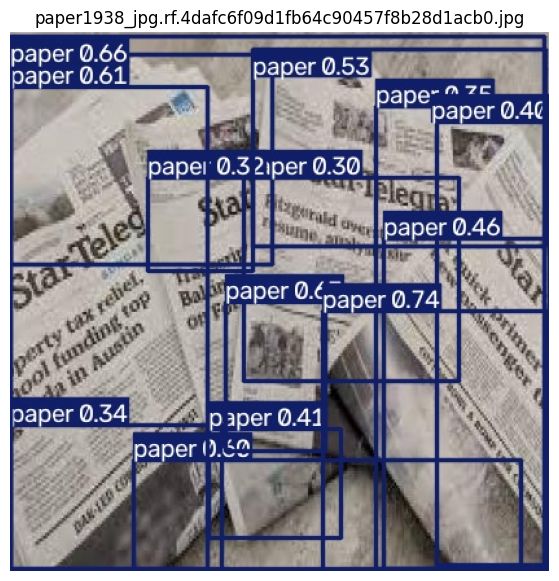

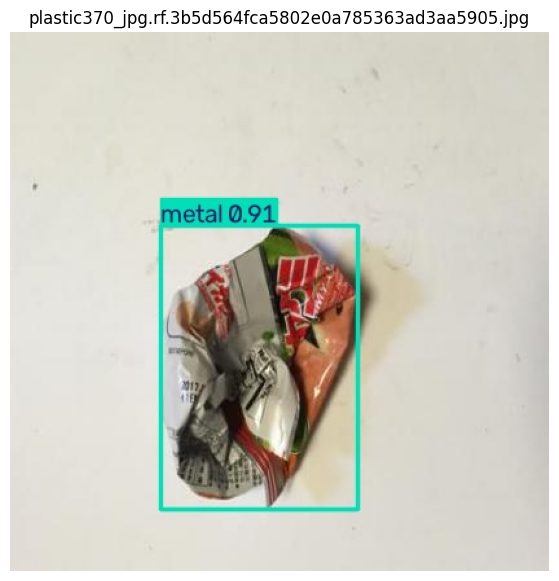

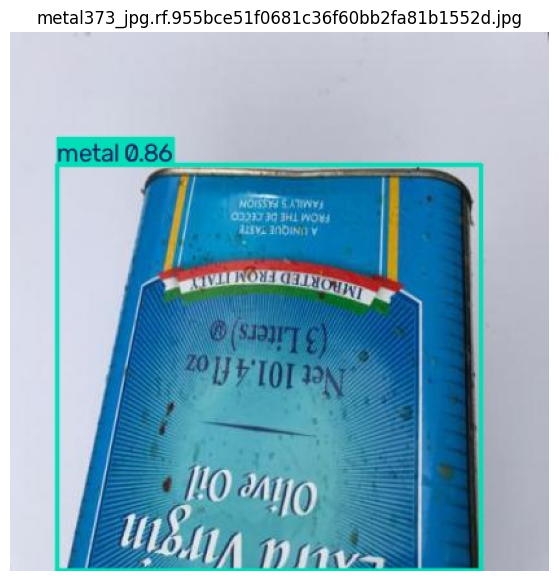

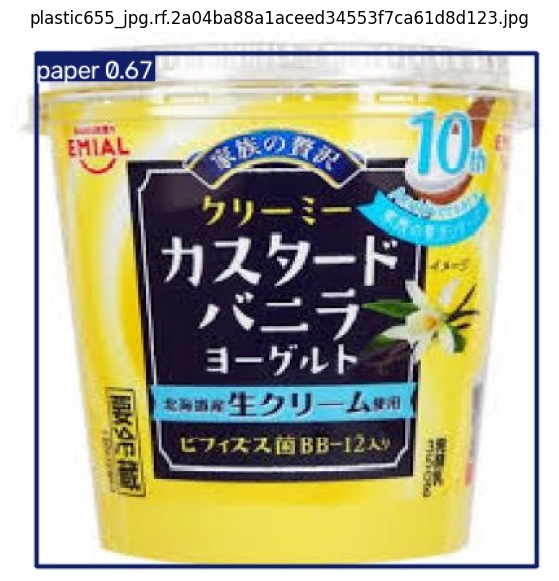

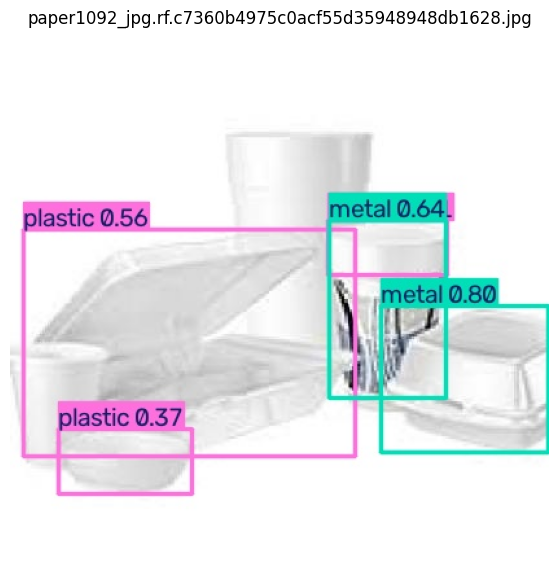

In [91]:
import matplotlib.pyplot as plt
from PIL import Image

images = (
    list(PRED_DIR.glob("*.jpg")) +
    list(PRED_DIR.glob("*.jpeg"))
)

for img_path in images[:6]:

    img = Image.open(img_path)

    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

In [92]:
from ultralytics import YOLO

MODEL_PATH = (
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "runs/yolov8n_merged_100ep/"
    "weights/best.pt"
)

model = YOLO(MODEL_PATH)

export_path = model.export(
    format="onnx",
    imgsz=640,
    simplify=True
)

print("Exported model:")
print(export_path)

Ultralytics 8.4.153 🚀 Python-3.10.12 torch-2.14.0+cu130 CPU (Intel Xeon w5-3435X)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/runs/yolov8n_merged_100ep/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/8.9 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 94.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/17.4 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 14.4/17.4 MB 72.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 70.4 M

In [94]:
from ultralytics import YOLO

ONNX_MODEL = (
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "runs/yolov8n_merged_100ep/weights/best.onnx"
)

DATA_YAML = (
    "/home/kumari-shikha/"
    "Garbage-Waste-Object-Detection-YOLOv8/"
    "data/garbage_yolo_merged/data.yaml"
)

model = YOLO(ONNX_MODEL)

metrics = model.val(
    data=DATA_YAML,
    imgsz=640,
    device=0
)

print("ONNX validation complete.")
print("mAP50    :", metrics.box.map50)
print("mAP50-95 :", metrics.box.map)

Ultralytics 8.4.153 🚀 Python-3.10.12 torch-2.14.0+cu130 CUDA:0 (NVIDIA RTX A5500, 24103MiB)
Loading /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/runs/yolov8n_merged_100ep/weights/best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/300.5 MB ? eta -:--:--
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/300.5 MB 31.9 MB/s eta 0:00:10
   ━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/300.5 MB 58.5 MB/s eta 0:00:05
   ━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/300.5 MB 72.2 MB/s eta 0:00:04
   ━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/300.5 MB 57.9 MB/s eta 0:00:05
   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/300.5 MB 65.1 MB/s eta 0:00:04
   ━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/300.5 MB 65.8 MB/s eta 0:00:04
   ━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/300.5 MB 67.4 MB/s eta 0:00:04
   ━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [95]:
%pip install -U coremltools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 13.9 MB/s  0:00:00 10.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [coremltools]━━━━━━ 2/3 [coremltools]
Note: you may need to restart the kernel to use updated packages.


In [96]:
import coremltools as ct

print("Core ML Tools:", ct.__version__)

Core ML Tools: 9.0


In [98]:
%pip install -U coremltools

Note: you may need to restart the kernel to use updated packages.


In [97]:
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/runs/yolov8n_merged_100ep/weights/best.onnx

NameError: name 'home' is not defined

In [1]:
import coremltools as ct

print("Core ML Tools:", ct.__version__)

Torch version 2.14.0+cu130 has not been tested with coremltools. You may run into unexpected errors. Torch 2.7.0 is the most recent version that has been tested.
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLCPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLGPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLNeuralEngineComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLComputePlanProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLModelAssetProxy: No module named 'coremltools.libcoremlpython'


Core ML Tools: 9.0


In [2]:
ONNX_MODEL = "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/runs/yolov8n_merged_100ep/weights/best.onnx"

print(ONNX_MODEL)

/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/runs/yolov8n_merged_100ep/weights/best.onnx


In [3]:
import onnx

ONNX_MODEL = "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/runs/yolov8n_merged_100ep/weights/best.onnx"

onnx_model = onnx.load(ONNX_MODEL)

print("ONNX model loaded successfully")
print("Inputs:")
for inp in onnx_model.graph.input:
    print(" ", inp.name)

print("\nOutputs:")
for out in onnx_model.graph.output:
    print(" ", out.name)

ONNX model loaded successfully
Inputs:
  images

Outputs:
  output0


In [6]:
import onnxruntime as ort

model_path = "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/runs/yolov8n_merged_100ep/weights/best.onnx"

session = ort.InferenceSession(
    model_path,
    providers=["CPUExecutionProvider"]
)

print("ONNX model loaded successfully!")

input_info = session.get_inputs()[0]
output_info = session.get_outputs()[0]

print("\nINPUT")
print("Name :", input_info.name)
print("Shape:", input_info.shape)
print("Type :", input_info.type)

print("\nOUTPUT")
print("Name :", output_info.name)
print("Shape:", output_info.shape)
print("Type :", output_info.type)

ONNX model loaded successfully!

INPUT
Name : images
Shape: [1, 3, 640, 640]
Type : tensor(float)

OUTPUT
Name : output0
Shape: [1, 10, 8400]
Type : tensor(float)


In [8]:
from pathlib import Path

base = Path("/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8")

test_dir = base / "data" / "garbage_raw" / "test"

print("Test directory:", test_dir)
print("Exists:", test_dir.exists())

test_images = (
    list(test_dir.glob("*.jpg")) +
    list(test_dir.glob("*.jpeg")) +
    list(test_dir.glob("*.png"))
)

print("Test images:", len(test_images))

for img in test_images[:10]:
    print(img)

Test directory: /home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_raw/test
Exists: True
Test images: 1042
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_raw/test/paper842_jpg.rf.9ab4cc19a05165a8041d37a0ce80074a.jpg
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_raw/test/paper1938_jpg.rf.4dafc6f09d1fb64c90457f8b28d1acb0.jpg
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_raw/test/plastic370_jpg.rf.3b5d564fca5802e0a785363ad3aa5905.jpg
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_raw/test/metal373_jpg.rf.955bce51f0681c36f60bb2fa81b1552d.jpg
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_raw/test/plastic655_jpg.rf.2a04ba88a1aceed34553f7ca61d8d123.jpg
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_raw/test/paper1092_jpg.rf.c7360b4975c0acf55d35948948db1628.jpg
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbag

In [19]:
image_path = str(test_images[58])

print("Testing image:")
print(image_path)

Testing image:
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_raw/test/plastic355_jpg.rf.ec6dc9f4b8904416df9c82e5646f0855.jpg


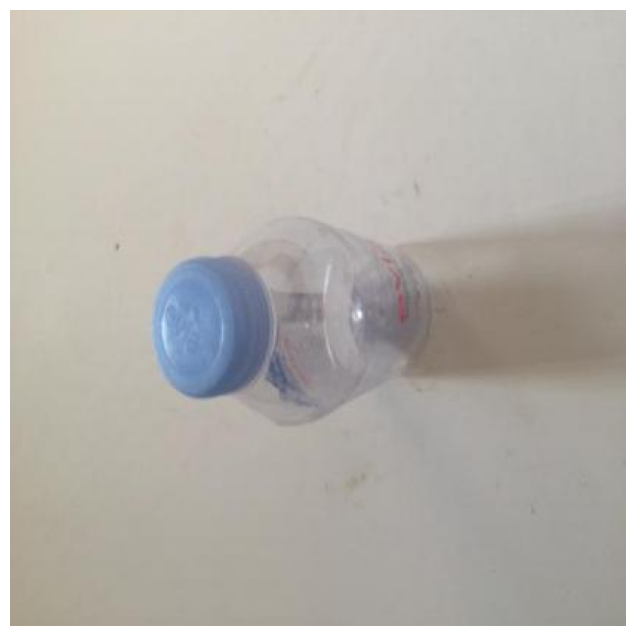

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_path)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [21]:
import cv2
import numpy as np

# Read image
image = cv2.imread(image_path)

# Keep original dimensions
original_h, original_w = image.shape[:2]

# Resize to YOLO input size
img = cv2.resize(image, (640, 640))

# BGR -> RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# HWC -> CHW
img = img.transpose(2, 0, 1)

# uint8 -> float32 and normalize
img = img.astype(np.float32) / 255.0

# Add batch dimension
img = np.expand_dims(img, axis=0)

print("Original image:", (original_w, original_h))
print("ONNX input:", img.shape)

# Run inference
outputs = session.run(
    ["output0"],
    {"images": img}
)

output = outputs[0]

print("ONNX output:", output.shape)
print("Output dtype:", output.dtype)
print("Output min:", output.min())
print("Output max:", output.max())

Original image: (416, 416)
ONNX input: (1, 3, 640, 640)
ONNX output: (1, 10, 8400)
Output dtype: float32
Output min: 0.0
Output max: 642.8886


In [22]:
# Remove batch dimension
pred = output[0]

print("Shape:", pred.shape)

# Show first 10 predictions
print("\nFirst 10 predictions:")
print(pred[:, :10])

Shape: (10, 8400)

First 10 predictions:
[[1.24521427e+01 2.64725189e+01 3.43083649e+01 4.16272583e+01
  4.20694122e+01 4.97042923e+01 6.43482361e+01 6.76167297e+01
  7.02613525e+01 7.39280396e+01]
 [1.03135853e+01 1.81327877e+01 1.44401245e+01 9.14647198e+00
  8.92667770e+00 7.94936991e+00 7.98440361e+00 7.55811310e+00
  6.50648022e+00 6.73710060e+00]
 [2.49485207e+01 5.30811844e+01 6.79055023e+01 8.12349548e+01
  8.65583038e+01 1.04957657e+02 1.35710022e+02 1.50306580e+02
  1.67662598e+02 1.73457703e+02]
 [2.05104561e+01 3.61476784e+01 2.88048477e+01 1.80372066e+01
  1.76847916e+01 1.56682711e+01 1.57246857e+01 1.49510307e+01
  1.29653854e+01 1.34283543e+01]
 [1.63912773e-06 2.68220901e-07 2.08616257e-07 0.00000000e+00
  8.94069672e-08 0.00000000e+00 0.00000000e+00 8.94069672e-08
  5.96046448e-08 1.49011612e-07]
 [6.55651093e-07 2.98023224e-07 1.19209290e-07 8.94069672e-08
  1.49011612e-07 5.96046448e-08 5.96046448e-08 5.96046448e-08
  5.96046448e-08 1.78813934e-07]
 [1.16229057e-06 

In [23]:
print("\nFirst candidate:")
print(pred[:, 0])

print("\nSecond candidate:")
print(pred[:, 1])


First candidate:
[1.2452143e+01 1.0313585e+01 2.4948521e+01 2.0510456e+01 1.6391277e-06
 6.5565109e-07 1.1622906e-06 8.6426735e-07 1.6987324e-06 3.5166740e-06]

Second candidate:
[2.6472519e+01 1.8132788e+01 5.3081184e+01 3.6147678e+01 2.6822090e-07
 2.9802322e-07 6.8545341e-07 2.6822090e-07 9.8347664e-07 1.9967556e-06]


In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Class names
class_names = [
    "biodegradable",
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic"
]

# Remove batch dimension
pred = output[0]   # (10, 8400)

# Transpose:
# (10, 8400) -> (8400, 10)
pred = pred.T

print("Prediction shape:", pred.shape)

# --------------------------------------------------
# 1. Extract boxes
# --------------------------------------------------

boxes = pred[:, :4]

# --------------------------------------------------
# 2. Extract class scores
# --------------------------------------------------

class_scores = pred[:, 4:]

# Best class for each prediction
class_ids = np.argmax(class_scores, axis=1)

# Confidence for best class
confidences = np.max(class_scores, axis=1)

print("Highest confidence:", confidences.max())

# --------------------------------------------------
# 3. Confidence filtering
# --------------------------------------------------

confidence_threshold = 0.25

mask = confidences > confidence_threshold

boxes = boxes[mask]
confidences = confidences[mask]
class_ids = class_ids[mask]

print("Detections after confidence filtering:", len(boxes))

Prediction shape: (8400, 10)
Highest confidence: 0.8918562
Detections after confidence filtering: 20


In [25]:
# Convert YOLO boxes:
# x_center, y_center, width, height
#
# into:
# x1, y1, x2, y2

xyxy_boxes = []

for box in boxes:
    x, y, w, h = box

    x1 = x - w / 2
    y1 = y - h / 2
    x2 = x + w / 2
    y2 = y + h / 2

    xyxy_boxes.append([x1, y1, x2, y2])

xyxy_boxes = np.array(xyxy_boxes)

# OpenCV NMS expects:
# [x, y, width, height]

nms_boxes = []

for box in xyxy_boxes:
    x1, y1, x2, y2 = box
    nms_boxes.append([
        float(x1),
        float(y1),
        float(x2 - x1),
        float(y2 - y1)
    ])

indices = cv2.dnn.NMSBoxes(
    nms_boxes,
    confidences.tolist(),
    score_threshold=0.25,
    nms_threshold=0.45
)

if len(indices) > 0:
    indices = indices.flatten()
else:
    indices = []

print("Final detections after NMS:", len(indices))

for i in indices:
    print(
        class_names[class_ids[i]],
        f"{confidences[i]:.3f}",
        xyxy_boxes[i]
    )

Final detections after NMS: 2
plastic 0.892 [145.64142 217.69177 437.53314 433.25287]
plastic 0.856 [147.40677 254.63617 271.96976 404.26373]


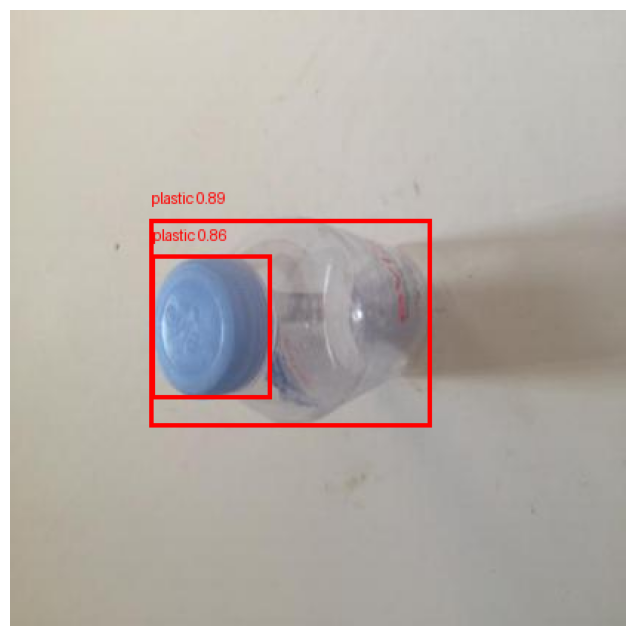

In [26]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# Load original image
original = Image.open(image_path).convert("RGB")

original_w, original_h = original.size

# Scale factors
scale_x = original_w / 640
scale_y = original_h / 640

# Create drawing image
draw_image = original.copy()
draw = ImageDraw.Draw(draw_image)

# Draw final detections
for i in indices:

    x1, y1, x2, y2 = xyxy_boxes[i]

    # Convert 640x640 coordinates -> original image coordinates
    x1 *= scale_x
    x2 *= scale_x
    y1 *= scale_y
    y2 *= scale_y

    class_id = int(class_ids[i])
    confidence = float(confidences[i])

    label = f"{class_names[class_id]} {confidence:.2f}"

    # Draw bounding box
    draw.rectangle(
        [x1, y1, x2, y2],
        outline="red",
        width=3
    )

    # Draw label
    draw.text(
        (x1, max(0, y1 - 20)),
        label,
        fill="red"
    )

# Display
plt.figure(figsize=(8, 8))
plt.imshow(draw_image)
plt.axis("off")
plt.show()

In [28]:
image_path = str(test_images[58])

print("Testing image:")
print(image_path)

Testing image:
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_raw/test/plastic355_jpg.rf.ec6dc9f4b8904416df9c82e5646f0855.jpg


In [29]:
from ultralytics import YOLO

pt_model_path = "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/runs/yolov8n_merged_100ep/weights/best.pt"

model_pt = YOLO(pt_model_path)

results = model_pt.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    verbose=False
)

result = results[0]

print("PyTorch detections:")
print("=" * 50)

for box, conf, cls in zip(
    result.boxes.xyxy.cpu().numpy(),
    result.boxes.conf.cpu().numpy(),
    result.boxes.cls.cpu().numpy()
):
    print(
        f"{class_names[int(cls)]} "
        f"{conf:.3f} "
        f"{box}"
    )

PyTorch detections:
plastic 0.892 [     94.666       141.5       284.4      281.62]
plastic 0.856 [     95.816      165.51      176.78      262.77]


In [30]:
from ultralytics import YOLO

# Exact same image used for ONNX testing
image_path = str(test_images[58])

print("Testing image:")
print(image_path)

# Load PyTorch model
pt_model_path = "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/runs/yolov8n_merged_100ep/weights/best.pt"

model_pt = YOLO(pt_model_path)

# Run inference
results = model_pt.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    verbose=False
)

result = results[0]

print("\nPyTorch detections:")
print("=" * 60)

for box, conf, cls in zip(
    result.boxes.xyxy.cpu().numpy(),
    result.boxes.conf.cpu().numpy(),
    result.boxes.cls.cpu().numpy()
):
    print(
        f"{class_names[int(cls)]:<15} "
        f"confidence={conf:.3f} "
        f"box={box}"
    )

Testing image:
/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/data/garbage_raw/test/plastic355_jpg.rf.ec6dc9f4b8904416df9c82e5646f0855.jpg

PyTorch detections:
plastic         confidence=0.892 box=[     94.666       141.5       284.4      281.62]
plastic         confidence=0.856 box=[     95.816      165.51      176.78      262.77]


In [31]:
import cv2
import numpy as np
import onnxruntime as ort

onnx_path = "/home/kumari-shikha/Garbage-Waste-Object-Detection-YOLOv8/runs/yolov8n_merged_100ep/weights/best.onnx"

session = ort.InferenceSession(
    onnx_path,
    providers=["CPUExecutionProvider"]
)

# Load image
img = cv2.imread(image_path)

print("Original image:", img.shape)

# Resize
img_resized = cv2.resize(img, (640, 640))

# BGR -> RGB
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

# HWC -> CHW
img_input = img_rgb.transpose(2, 0, 1)

# uint8 -> float32
img_input = img_input.astype(np.float32) / 255.0

# Add batch dimension
img_input = np.expand_dims(img_input, axis=0)

print("ONNX input:", img_input.shape)

# Inference
output = session.run(
    ["output0"],
    {"images": img_input}
)[0]

print("ONNX output:", output.shape)
print("Output min:", output.min())
print("Output max:", output.max())

# Inspect the first 10 predictions
pred = output[0].T

print("\nTransposed prediction shape:", pred.shape)

print("\nFirst 5 predictions:")
print(pred[:5])

Original image: (416, 416, 3)
ONNX input: (1, 3, 640, 640)
ONNX output: (1, 10, 8400)
Output min: 0.0
Output max: 642.8886

Transposed prediction shape: (8400, 10)

First 5 predictions:
[[     12.452      10.314      24.949       20.51  1.6391e-06  6.5565e-07  1.1623e-06  8.6427e-07  1.6987e-06  3.5167e-06]
 [     26.473      18.133      53.081      36.148  2.6822e-07  2.9802e-07  6.8545e-07  2.6822e-07  9.8348e-07  1.9968e-06]
 [     34.308       14.44      67.906      28.805  2.0862e-07  1.1921e-07  7.7486e-07  1.1921e-07  7.7486e-07  1.3113e-06]
 [     41.627      9.1465      81.235      18.037           0  8.9407e-08  3.5763e-07  8.9407e-08  3.5763e-07  3.8743e-07]
 [     42.069      8.9267      86.558      17.685  8.9407e-08  1.4901e-07  4.7684e-07           0  3.5763e-07  5.6624e-07]]


In [32]:
# Find highest-confidence ONNX predictions
pred = output[0].T   # (8400, 10)

boxes = pred[:, :4]
class_scores = pred[:, 4:]

class_ids = np.argmax(class_scores, axis=1)
confidences = np.max(class_scores, axis=1)

# Get top 20 predictions
top_indices = np.argsort(confidences)[::-1][:20]

print("Top 20 raw ONNX predictions")
print("=" * 80)

for i, idx in enumerate(top_indices):
    print(
        f"{i+1:2d}. "
        f"class={class_names[class_ids[idx]]:<15} "
        f"confidence={confidences[idx]:.4f} "
        f"box={boxes[idx]}"
    )

Top 20 raw ONNX predictions
 1. class=plastic         confidence=0.8919 box=[     291.59      325.47      291.89      215.56]
 2. class=plastic         confidence=0.8823 box=[     291.83      325.41      291.36      215.73]
 3. class=plastic         confidence=0.8803 box=[     292.12      323.95      291.97      216.51]
 4. class=plastic         confidence=0.8624 box=[     292.26      325.13      292.44      218.37]
 5. class=plastic         confidence=0.8619 box=[     291.53      325.73      291.17      216.96]
 6. class=plastic         confidence=0.8588 box=[     291.72      325.57       291.9      216.19]
 7. class=plastic         confidence=0.8561 box=[     209.69      329.45      124.56      149.63]
 8. class=plastic         confidence=0.8536 box=[     209.48      329.47      126.17      149.52]
 9. class=plastic         confidence=0.8504 box=[     209.74      331.26      126.75      152.53]
10. class=plastic         confidence=0.8442 box=[      209.5       329.2      126.19      

In [33]:
import cv2
import numpy as np

# ONNX predictions
pred = output[0].T   # (8400, 10)

# Separate boxes and class scores
boxes_xywh = pred[:, :4]
class_scores = pred[:, 4:]

# Best class for each prediction
class_ids = np.argmax(class_scores, axis=1)
confidences = np.max(class_scores, axis=1)

# Confidence threshold
confidence_threshold = 0.25

mask = confidences >= confidence_threshold

boxes_xywh = boxes_xywh[mask]
confidences = confidences[mask]
class_ids = class_ids[mask]

print("Candidates after confidence filtering:", len(boxes_xywh))

# Convert xywh -> xyxy
boxes_xyxy = np.zeros_like(boxes_xywh)

boxes_xyxy[:, 0] = boxes_xywh[:, 0] - boxes_xywh[:, 2] / 2  # x1
boxes_xyxy[:, 1] = boxes_xywh[:, 1] - boxes_xywh[:, 3] / 2  # y1
boxes_xyxy[:, 2] = boxes_xywh[:, 0] + boxes_xywh[:, 2] / 2  # x2
boxes_xyxy[:, 3] = boxes_xywh[:, 1] + boxes_xywh[:, 3] / 2  # y2

# Clip to 640x640 image
boxes_xyxy[:, [0, 2]] = np.clip(boxes_xyxy[:, [0, 2]], 0, 640)
boxes_xyxy[:, [1, 3]] = np.clip(boxes_xyxy[:, [1, 3]], 0, 640)

# NMS
nms_indices = cv2.dnn.NMSBoxes(
    boxes_xyxy.tolist(),
    confidences.tolist(),
    score_threshold=confidence_threshold,
    nms_threshold=0.45
)

print("Final detections:", len(nms_indices))

for i in nms_indices:
    i = int(i)

    print(
        f"{class_names[class_ids[i]]:<15} "
        f"confidence={confidences[i]:.3f} "
        f"box={boxes_xyxy[i]}"
    )

Candidates after confidence filtering: 20
Final detections: 1
plastic         confidence=0.892 box=[     145.64      217.69      437.53      433.25]


In [34]:
# Convert 640x640 coordinates back to original image size

original_img = cv2.imread(image_path)

orig_h, orig_w = original_img.shape[:2]

scale_x = orig_w / 640
scale_y = orig_h / 640

print("Original size:", orig_w, "x", orig_h)
print("Scale:", scale_x, scale_y)

# Take final NMS detections
final_boxes = boxes_xyxy[nms_indices.flatten()]
final_scores = confidences[nms_indices.flatten()]
final_classes = class_ids[nms_indices.flatten()]

# Scale coordinates
final_boxes_original = final_boxes.copy()

final_boxes_original[:, [0, 2]] *= scale_x
final_boxes_original[:, [1, 3]] *= scale_y

print("\nONNX detections in original image coordinates:")
print("=" * 60)

for box, score, cls in zip(
    final_boxes_original,
    final_scores,
    final_classes
):
    print(
        f"{class_names[cls]:<15} "
        f"confidence={score:.3f} "
        f"box={box}"
    )

Original size: 416 x 416
Scale: 0.65 0.65

ONNX detections in original image coordinates:
plastic         confidence=0.892 box=[     94.667       141.5       284.4      281.61]


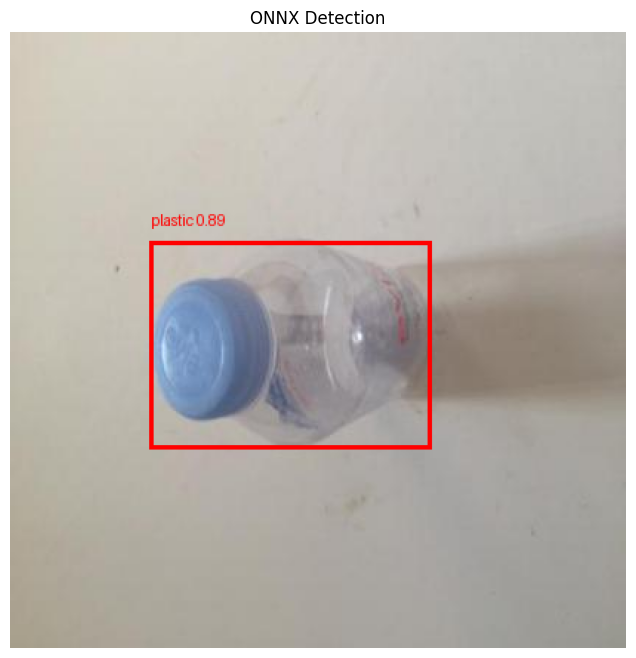

In [35]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB")

draw = ImageDraw.Draw(image)

for box, score, cls in zip(
    final_boxes_original,
    final_scores,
    final_classes
):
    x1, y1, x2, y2 = box

    draw.rectangle(
        [x1, y1, x2, y2],
        outline="red",
        width=3
    )

    label = f"{class_names[cls]} {score:.2f}"

    draw.text(
        (x1, max(0, y1 - 20)),
        label,
        fill="red"
    )

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.title("ONNX Detection")
plt.show()